# Ratemap Smoothing Slider

Load one random **unsmoothed** ratemap and explore Gaussian smoothing with `sigma` in **20 values between 1 and 10**.


In [12]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

HAS_WIDGETS = False

# Make local package importable
REPO_ROOT = Path('..').resolve()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from placefields.metrics import smooth_last_axis

plt.style.use('default')


In [13]:
# --- Config ---
RMAP_ROOT = REPO_ROOT / 'results' / 'ratemap'
RNG_SEED = None  # set int for reproducibility

rng = np.random.default_rng(RNG_SEED)

# Discover ratemap files
rmap_files = sorted(RMAP_ROOT.rglob('*_rmap.npz'))
if not rmap_files:
    raise FileNotFoundError(f'No ratemap files found under {RMAP_ROOT}')

rmap_path = rmap_files[int(rng.integers(0, len(rmap_files)))]
print('Random ratemap file:', rmap_path)

with np.load(rmap_path, allow_pickle=False) as z:
    required = ['cell_ids', 'rmap__fr_cx_ux']
    missing = [k for k in required if k not in z.files]
    if missing:
        raise KeyError(f'Missing keys in {rmap_path.name}: {missing}')

    cell_ids = z['cell_ids'].astype(np.int64)
    fr_cx_ux = z['rmap__fr_cx_ux'].astype(np.float64)  # (cells, cond, bins)

n_cells, n_cond, n_bins = fr_cx_ux.shape
u = int(rng.integers(0, n_cells))
c = int(rng.integers(0, n_cond))

cell_id = int(cell_ids[u])
fr_raw_x = fr_cx_ux[u, c, :]

print(f'Random selection -> cell_id={cell_id}, cond={c + 1}/{n_cond}, bins={n_bins}')


Random ratemap file: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\results\ratemap\VS12\2022-02-26\VS12_2022-02-26_12-01-52_rmap.npz
Random selection -> cell_id=1, cond=4/4, bins=100


In [14]:
# 20 sigma values from 1 to 10
sigma_values = np.linspace(1.0, 10.0, 20)

# Precompute smoothed curves for responsiveness in the slider
smoothed = {float(s): smooth_last_axis(fr_raw_x, float(s)) for s in sigma_values}

x = np.arange(fr_raw_x.size)

print('Sigma grid:')
print(np.round(sigma_values, 3))


Sigma grid:
[ 1.     1.474  1.947  2.421  2.895  3.368  3.842  4.316  4.789  5.263
  5.737  6.211  6.684  7.158  7.632  8.105  8.579  9.053  9.526 10.   ]


ipywidgets not available; showing all 20 sigma curves in a grid.


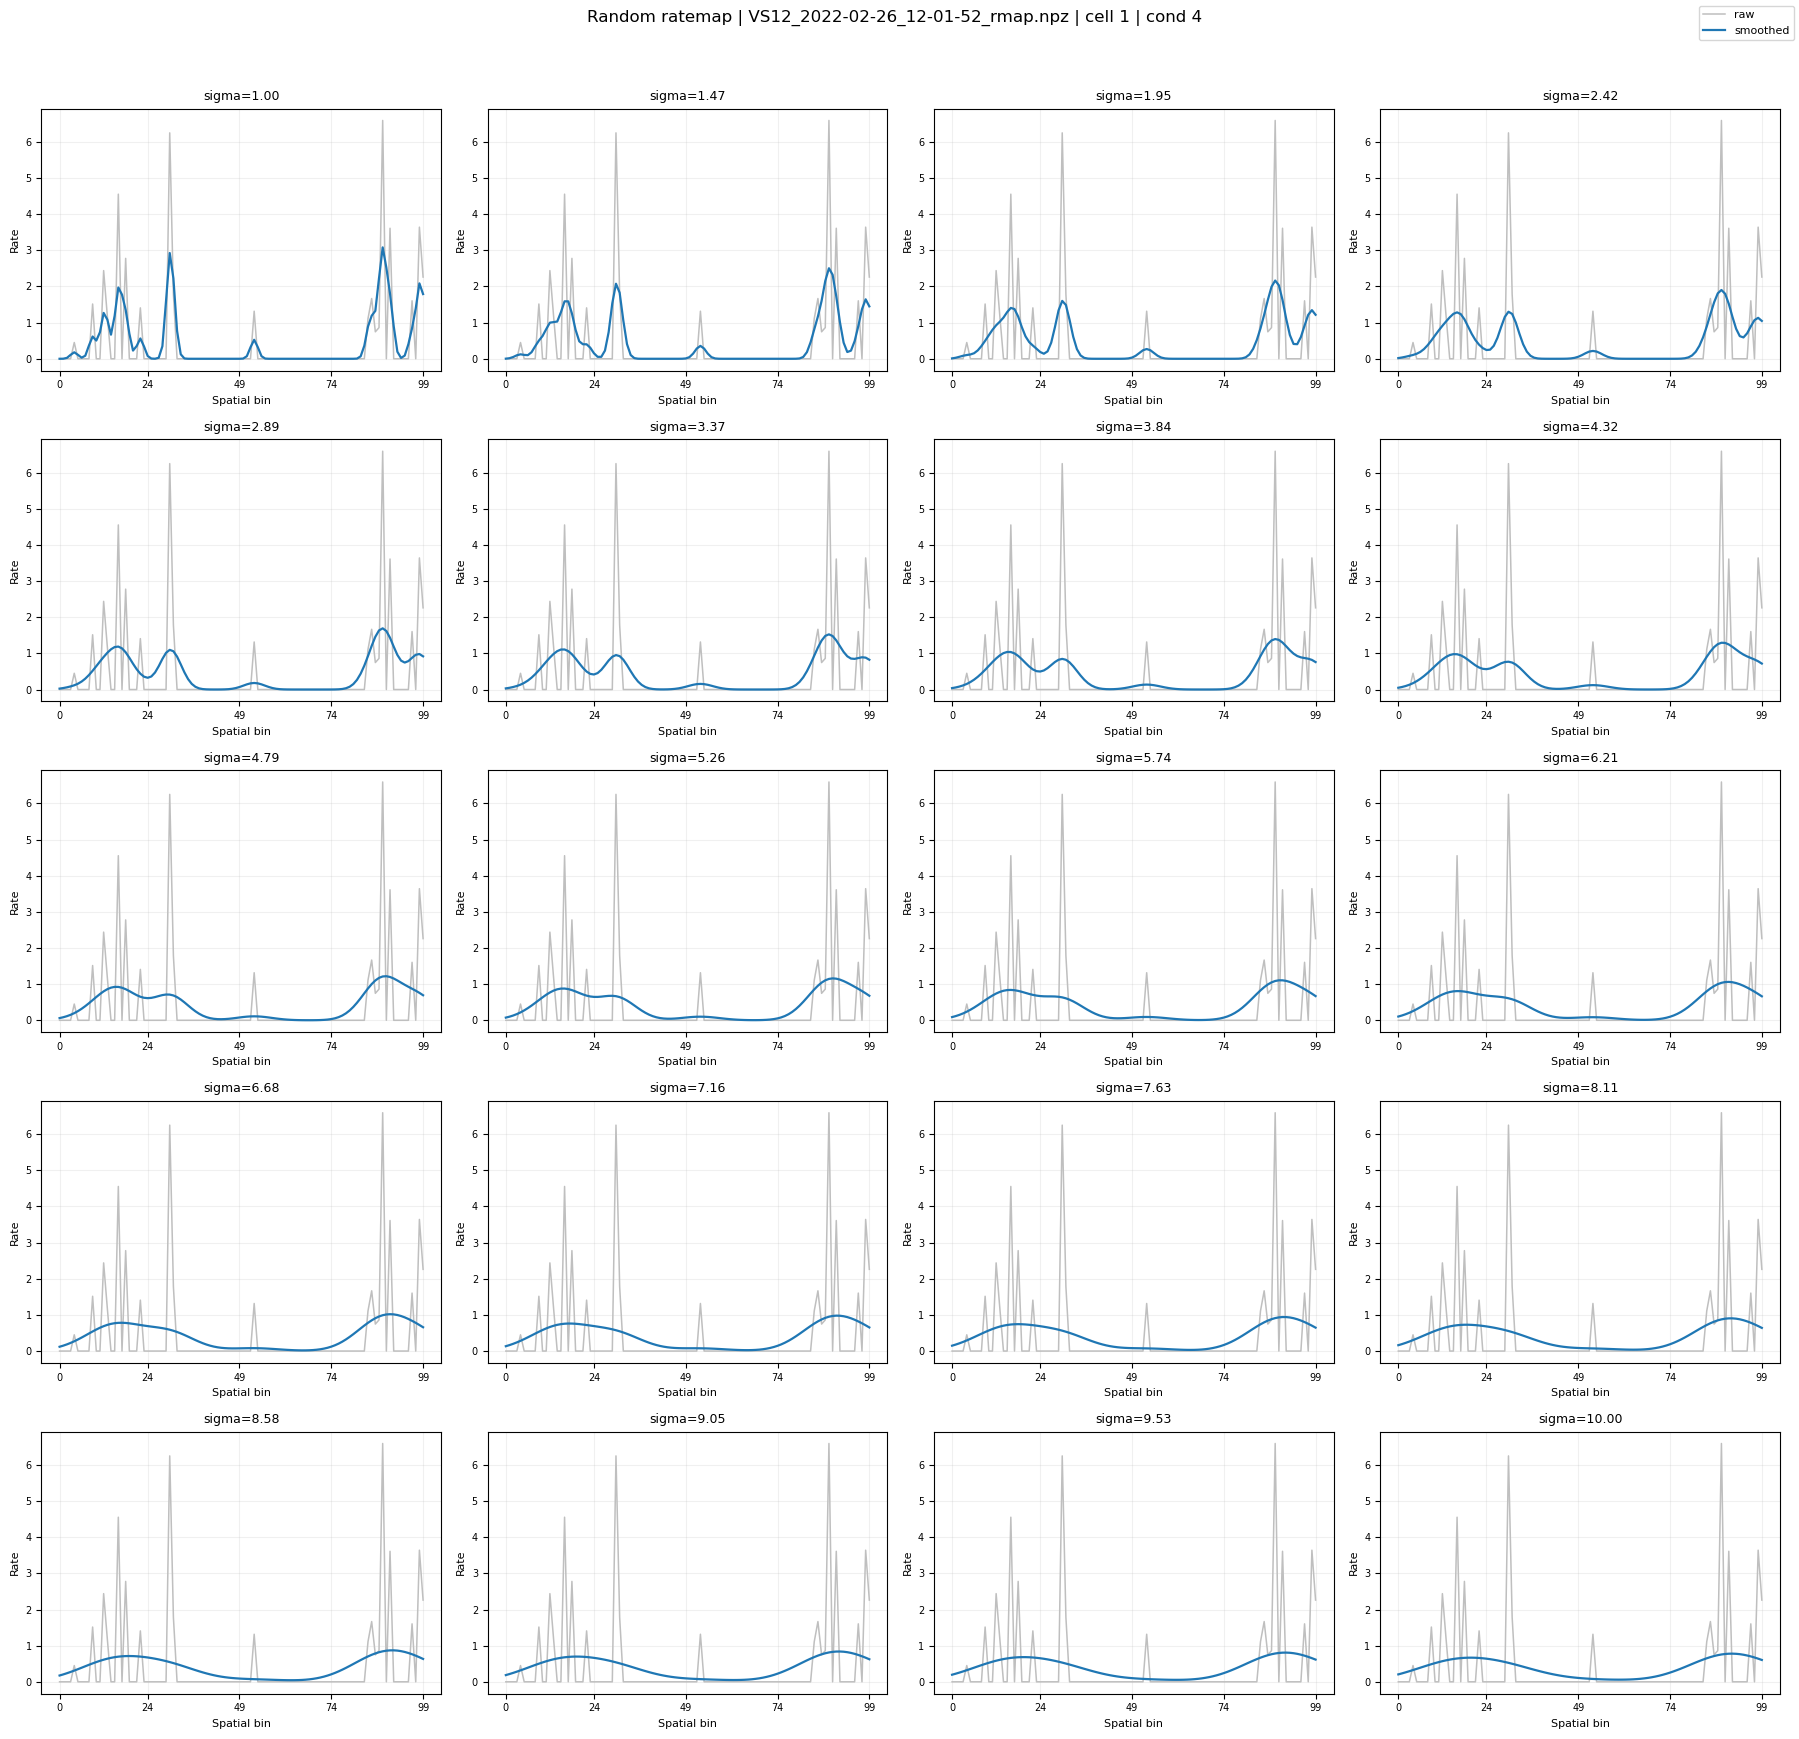

In [15]:
def plot_smoothed(sigma):
    sigma = float(sigma)
    y = smoothed[sigma]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, fr_raw_x, color='0.65', linewidth=1.8, label='unsmoothed')
    ax.plot(x, y, color='#1f77b4', linewidth=2.2, label=f'smoothed (sigma={sigma:.3g})')
    ax.set_title(f'Random ratemap | {rmap_path.name} | cell {cell_id} | cond {c + 1}')
    ax.set_xlabel('Spatial bin')
    ax.set_ylabel('Rate')

    xt = np.unique(np.linspace(0, fr_raw_x.size - 1, 6, dtype=int))
    ax.set_xticks(xt)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(alpha=0.2)
    ax.legend(loc='best')
    plt.show()

if HAS_WIDGETS:
    slider = widgets.SelectionSlider(
        options=[float(s) for s in sigma_values],
        value=float(sigma_values[0]),
        description='sigma',
        continuous_update=False,
        readout_format='.3g',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='700px'),
    )
    widgets.interact(plot_smoothed, sigma=slider)
else:
    print('ipywidgets not available; showing all 20 sigma curves in a grid.')
    n_cols = 4
    n_rows = int(np.ceil(len(sigma_values) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.4 * n_rows), squeeze=False)
    axes = axes.ravel()
    xt = np.unique(np.linspace(0, fr_raw_x.size - 1, 5, dtype=int))

    for i, s in enumerate(sigma_values):
        ax = axes[i]
        y = smoothed[float(s)]
        ax.plot(x, fr_raw_x, color='0.75', linewidth=1.1, label='raw')
        ax.plot(x, y, color='#1f77b4', linewidth=1.6, label='smoothed')
        ax.set_title(f'sigma={s:.2f}', fontsize=9)
        ax.set_xlabel('Spatial bin', fontsize=8)
        ax.set_ylabel('Rate', fontsize=8)
        ax.set_xticks(xt)
        ax.tick_params(axis='both', labelsize=7)
        ax.grid(alpha=0.18)

    for j in range(len(sigma_values), len(axes)):
        axes[j].axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=8)
    fig.suptitle(f'Random ratemap | {rmap_path.name} | cell {cell_id} | cond {c + 1}', y=1.02)
    fig.tight_layout()
    plt.show()


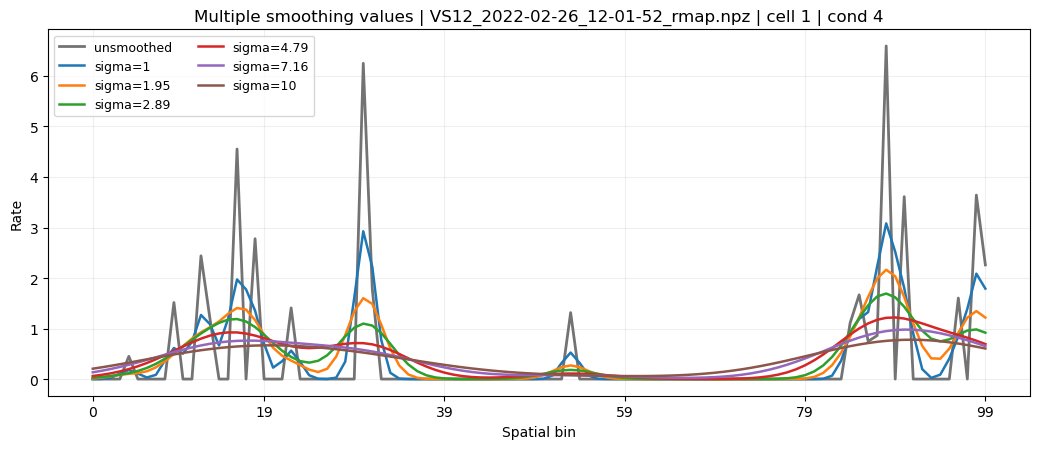

In [16]:
# Overlay several smoothing values on the same ratemap
SIGMA_COMPARE = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.plot(x, fr_raw_x, color='0.45', linewidth=2.0, label='unsmoothed')

for s in SIGMA_COMPARE:
    s = float(s)
    if s not in smoothed:
        # If a value is not exactly in sigma_values, use nearest available.
        s = float(sigma_values[np.argmin(np.abs(sigma_values - s))])
    ax.plot(x, smoothed[s], linewidth=1.8, label=f'sigma={s:.3g}')

ax.set_title(f'Multiple smoothing values | {rmap_path.name} | cell {cell_id} | cond {c + 1}')
ax.set_xlabel('Spatial bin')
ax.set_ylabel('Rate')
ax.set_xticks(np.unique(np.linspace(0, fr_raw_x.size - 1, 6, dtype=int)))
ax.tick_params(axis='both', labelsize=10)
ax.grid(alpha=0.2)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
